# Parte V. Conjuntos frecuentes y reglas de asociación

**Integrantes:** Ricardo Amiel Acuña Villogas, Juan Leibniz Aquino Espinoza y Camilo Ernesto Soto Cristóbal.

**La decisión que determina todo el resultado es qué se considera una transacción.** El enunciado pide justificarla, y aquí se justifica con una medición y no con una intuición, porque la definición obvia resultó no servir.

**Pregunta concreta que hereda de la Parte I.** Quedó un suelo de procesos sin competencia efectiva que atraviesa todos los tramos de monto. Falta saber si se reparte al azar o se concentra en combinaciones específicas de rubro, método y nivel de gobierno. Eso es una pregunta de patrones frecuentes.

In [ ]:
import sys, time
from pathlib import Path

# Los ayudantes del proyecto viven en notebooks/scripts. Se importan por
# nombre, no con asterisco, para que quede claro de donde sale cada uno.
RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(RAIZ / "notebooks" / "scripts"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pyspark.sql import Window
from pyspark.sql import functions as F

from scripts.helpers import (PARQUET, FIGS, ARTEFACTOS, FIGURAS, PALETA,
                     AZUL, ROJO, VERDE, MORADO, TEAL, TINTA, SUAVE, fmt,
                     abrir_spark, cronometro, medir, figura, exportar,
                     barras_h, lineas, barras_agrupadas, mapa_calor, lorenz, gini)
from scripts.algoritmos import apriori, reglas
from scripts.ingesta import catalogo_items

pd.set_option("display.width", 190)
pd.set_option("display.max_colwidth", 64)


spark = abrir_spark("P5-Reglas")
datos = spark.read.parquet(str(PARQUET))
datos.createOrReplaceTempView("contrataciones")
print(f"{datos.count():,} procesos")

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/10/01 16:08:26 WARN Utils: Your hostname, germain-ThinkPad-E15-Gen-2, resolves to a loopback address: 127.0.1.1; using 10.100.177.85 instead (on interface wlp0s20f3)
26/10/01 16:08:26 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address


Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/10/01 16:08:27 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


177,398 procesos


## 1. Qué es una transacción aquí

La definición natural es que cada proceso es una canasta de códigos CUBSO. Se mide antes de usarla, junto con dos alternativas que agrupan por entidad y período.


Lectura de f34_definicion_transaccion
Esta figura decide la parte entera, y da una respuesta incómoda: la definición natural no sirve. Solo el 2.1 % de los procesos tiene dos o más ítems, con un tamaño medio de canasta de 0.74. Un conjunto de un solo elemento no contiene coocurrencia, así que A-Priori y FP-Growth sobre esa definición devolverían únicamente conjuntos de tamaño uno, es decir un ranking de frecuencias disfrazado de minería de patrones. El motivo es que el catálogo CUBSO identifica el objeto del proceso y la mayoría de los procesos peruanos tienen un objeto único: la analogía del supermercado no se sostiene a nivel de acto administrativo. Agrupar por entidad y mes sube la coocurrencia al 53.6 % con tamaño medio 2.78, y es la definición que se adopta.



,definicion,canastas,tam_medio,tam_mediano,tam_max,con_dos_o_mas,pct_coocurrencia
0,un proceso,177398,0.74,1,130,3694,2.1
1,una entidad en un mes,37114,2.78,2,191,19911,53.6
2,una entidad en un trimestre,21098,4.49,2,337,14348,68.0


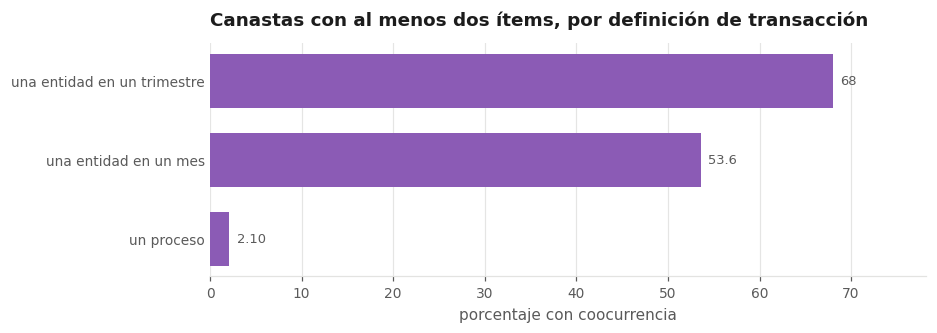

In [2]:
base = datos.filter("n_items > 0").withColumn("item", F.explode("items"))

def describir(df, etiqueta):
    d = df.withColumn("t", F.size("items_set"))
    r = d.select(F.count("*").alias("canastas"),
                 F.round(F.mean("t"), 2).alias("tam_medio"),
                 F.expr("percentile_approx(t, 0.5)").alias("tam_mediano"),
                 F.max("t").alias("tam_max"),
                 F.sum((F.col("t") > 1).cast("int")).alias("con_dos_o_mas")).collect()[0].asDict()
    r["definicion"] = etiqueta
    r["pct_coocurrencia"] = round(100 * r["con_dos_o_mas"] / r["canastas"], 1)
    return r

natural = datos.select(F.col("items").alias("items_set"))
por_mes = (base.groupBy("comprador_id", "anio_mes")
           .agg(F.collect_set("item").alias("items_set")))
por_trim = (base.withColumn("trim", F.concat_ws("T", F.col("anio"), F.ceil(F.col("mes") / 3)))
            .groupBy("comprador_id", "trim").agg(F.collect_set("item").alias("items_set")))

cmp = pd.DataFrame([describir(natural, "un proceso"),
                    describir(por_mes, "una entidad en un mes"),
                    describir(por_trim, "una entidad en un trimestre")])
cmp = cmp[["definicion", "canastas", "tam_medio", "tam_mediano", "tam_max",
           "con_dos_o_mas", "pct_coocurrencia"]]
exportar(cmp, "p5_definicion_transaccion", "Tres definiciones de transaccion, medidas")

fig, _ = barras_h(cmp, "definicion", "pct_coocurrencia",
                  "Canastas con al menos dos ítems, por definición de transacción",
                  "porcentaje con coocurrencia", color=MORADO, alto=0.55)
nat, mes = cmp.iloc[0], cmp.iloc[1]
figura(fig, "f34_definicion_transaccion", f"""
Esta figura decide la parte entera, y da una respuesta incómoda: la definición natural no sirve.
Solo el {nat.pct_coocurrencia} % de los procesos tiene dos o más ítems, con un tamaño medio de
canasta de {nat.tam_medio}. Un conjunto de un solo elemento no contiene coocurrencia, así que
A-Priori y FP-Growth sobre esa definición devolverían únicamente conjuntos de tamaño uno, es
decir un ranking de frecuencias disfrazado de minería de patrones. El motivo es que el catálogo
CUBSO identifica el objeto del proceso y la mayoría de los procesos peruanos tienen un objeto
único: la analogía del supermercado no se sostiene a nivel de acto administrativo. Agrupar por
entidad y mes sube la coocurrencia al {mes.pct_coocurrencia} % con tamaño medio {mes.tam_medio},
y es la definición que se adopta.""")
cmp

Se adopta la ventana mensual y no la trimestral por dos razones. Conserva más transacciones, y un mismo umbral de soporte relativo es más exigente cuando hay más transacciones. Y es interpretable: la regla dice que la entidad que compra A compra también B dentro del mismo mes, que describe un patrón de abastecimiento. A escala trimestral la coocurrencia empieza a capturar simplemente que la entidad compra mucho.

In [3]:
canastas = [list(r.items_set) for r in por_mes.select("items_set").collect()]
canastas = [c for c in canastas if len(c) >= 2]          # las unitarias no aportan nada
transacciones = [set(c) for c in canastas]
universo = len({i for t in transacciones for i in t})
print(f"{len(transacciones):,} transacciones minables, {universo:,} items distintos")
print(f"tamano medio {np.mean([len(t) for t in transacciones]):.2f}, "
      f"maximo {max(len(t) for t in transacciones)}")

catalogo = {r.item: r.nombre for r in catalogo_items(spark).collect()}
nombre = lambda c: catalogo.get(c, c)[:46]

19,911 transacciones minables, 4,597 items distintos
tamano medio 4.32, maximo 191


## 2. A-Priori

Procede por niveles y se apoya en la antimonotonía: si un conjunto no es frecuente, ningún superconjunto suyo puede serlo. Eso poda el espacio de búsqueda, pero obliga a una pasada completa por las transacciones en cada nivel, y ese es su costo.

In [4]:
SOPORTE = 0.005
muestra_t = transacciones[:8000]      # A-Priori no escala al conjunto completo

t0 = time.perf_counter()
frec_apriori = apriori(muestra_t, SOPORTE)
t_apriori = time.perf_counter() - t0

por_tam = pd.Series([len(k) for k in frec_apriori]).value_counts().sort_index()
print(f"A-Priori sobre {len(muestra_t):,} transacciones, soporte {SOPORTE}: "
      f"{len(frec_apriori):,} conjuntos frecuentes en {t_apriori:.1f} s")
print("conjuntos por tamano:", por_tam.to_dict())

A-Priori sobre 8,000 transacciones, soporte 0.005: 202 conjuntos frecuentes en 3.0 s
conjuntos por tamano: {1: 132, 2: 68, 3: 2}


## 3. FP-Growth con Spark MLlib

Comprime las transacciones en un árbol de prefijos y mina por proyecciones condicionales, sin generar candidatos. Dos pasadas por el dato en lugar de una por nivel.

In [5]:
from pyspark.ml.fpm import FPGrowth
from pyspark.sql import Row

df_muestra = spark.createDataFrame([Row(items=list(t)) for t in muestra_t])
t0 = time.perf_counter()
fp_muestra = FPGrowth(itemsCol="items", minSupport=SOPORTE, minConfidence=0.3).fit(df_muestra)
frec_fp = {frozenset(r["items"]): r["freq"] / len(muestra_t)
           for r in fp_muestra.freqItemsets.collect()}
t_fp = time.perf_counter() - t0
print(f"FP-Growth sobre las mismas {len(muestra_t):,} transacciones: "
      f"{len(frec_fp):,} conjuntos en {t_fp:.1f} s")

FP-Growth sobre las mismas 8,000 transacciones: 202 conjuntos en 1.8 s


In [6]:
# Verificacion: los dos algoritmos deben devolver exactamente los mismos conjuntos.
solo_a = set(frec_apriori) - set(frec_fp)
solo_f = set(frec_fp) - set(frec_apriori)
difs = [abs(frec_apriori[k] - frec_fp[k]) for k in set(frec_apriori) & set(frec_fp)]
print(f"conjuntos solo en A-Priori: {len(solo_a)}   solo en FP-Growth: {len(solo_f)}")
print(f"maxima diferencia de soporte en los comunes: {max(difs) if difs else 0:.8f}")
print(f"coinciden: {not solo_a and not solo_f}")

conjuntos solo en A-Priori: 0   solo en FP-Growth: 0
maxima diferencia de soporte en los comunes: 0.00000000
coinciden: True



Lectura de f35_apriori_vs_fpgrowth
Con soporte alto los dos cuestan parecido porque hay pocos conjuntos frecuentes y A-Priori poda casi todo en el primer nivel. Al bajar el umbral de 0.02 a 0.0025 el número de conjuntos pasa de 34 a 554 y A-Priori pasa de 0.17 s a 19.27 s, mientras que FP-Growth se mantiene en el entorno de 0.44 s. La diferencia es estructural: A-Priori genera y cuenta candidatos nivel por nivel, de modo que el número de candidatos explota cuando el umbral baja, y FP-Growth no genera candidatos en absoluto. Esa es exactamente la razón por la que el segundo desplazó al primero.



,soporte,conjuntos,apriori_s,fpgrowth_s
0,0.0200,34,0.17,0.45
1,0.0100,80,0.67,0.37
2,0.0050,202,2.99,0.42
3,0.0025,554,19.27,0.44


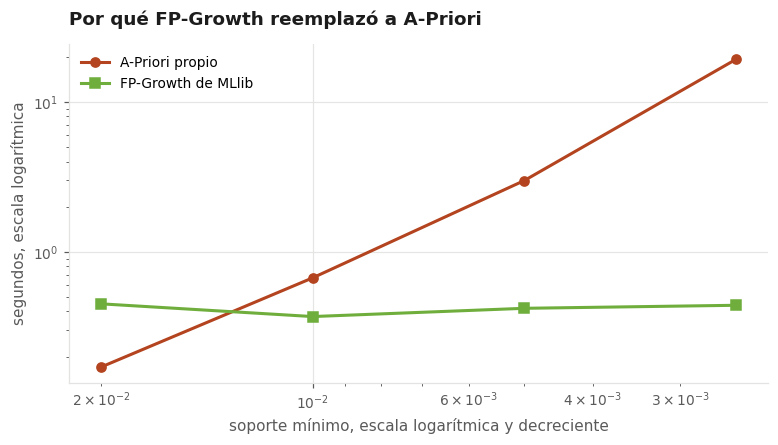

In [7]:
# El costo de cada uno segun el umbral de soporte.
filas = []
for sop in (0.02, 0.01, 0.005, 0.0025):
    t0 = time.perf_counter(); fa = apriori(muestra_t, sop); ta = time.perf_counter() - t0
    t0 = time.perf_counter()
    m = FPGrowth(itemsCol="items", minSupport=sop, minConfidence=0.3).fit(df_muestra)
    nf = m.freqItemsets.count(); tf = time.perf_counter() - t0
    filas.append({"soporte": sop, "conjuntos": len(fa),
                  "apriori_s": round(ta, 2), "fpgrowth_s": round(tf, 2)})
costo = pd.DataFrame(filas)
exportar(costo, "p5_costo_algoritmos", "Tiempo de A-Priori y FP-Growth segun el soporte minimo")

fig, ax = plt.subplots(figsize=(8.2, 4))
ax.plot(costo.soporte, costo.apriori_s, "o-", color=ROJO, lw=2, label="A-Priori propio")
ax.plot(costo.soporte, costo.fpgrowth_s, "s-", color=VERDE, lw=2, label="FP-Growth de MLlib")
ax.set_xscale("log"); ax.set_yscale("log"); ax.invert_xaxis()
ax.set_xlabel("soporte mínimo, escala logarítmica y decreciente")
ax.set_ylabel("segundos, escala logarítmica")
ax.set_title("Por qué FP-Growth reemplazó a A-Priori", loc="left", pad=12)
ax.grid(alpha=.9); ax.set_axisbelow(True); ax.legend()
alto, bajo = costo.iloc[0], costo.iloc[-1]
figura(fig, "f35_apriori_vs_fpgrowth", f"""
Con soporte alto los dos cuestan parecido porque hay pocos conjuntos frecuentes y A-Priori poda
casi todo en el primer nivel. Al bajar el umbral de {alto.soporte} a {bajo.soporte} el número de
conjuntos pasa de {int(alto.conjuntos)} a {int(bajo.conjuntos)} y A-Priori pasa de
{alto.apriori_s} s a {bajo.apriori_s} s, mientras que FP-Growth se mantiene en el entorno de
{bajo.fpgrowth_s} s. La diferencia es estructural: A-Priori genera y cuenta candidatos nivel por
nivel, de modo que el número de candidatos explota cuando el umbral baja, y FP-Growth no genera
candidatos en absoluto. Esa es exactamente la razón por la que el segundo desplazó al primero.""")
costo

Verificar que los dos coinciden sobre la misma muestra es lo que permite confiar en FP-Growth para el conjunto completo. A-Priori queda como implementación de referencia y FP-Growth como la que se usa en producción.

## 4. Reglas sobre el conjunto completo

Soporte, confianza y lift. El lift es el que distingue una asociación real de una coincidencia por frecuencia: una confianza alta sobre un ítem que ya aparece en casi todas las transacciones no dice nada.

218 reglas con soporte >= 0.002 y confianza >= 0.3



Lectura de f36_reglas
La nube muestra el compromiso central de la minería de reglas. Las reglas de soporte alto tienen lift cercano a uno: describen ítems que coinciden por ser ambos frecuentes, no porque uno prediga al otro. Las de lift alto viven en la zona de soporte bajo, donde el patrón es fuerte pero afecta a pocas transacciones. El máximo de lift es 139, es decir que ese par aparece junto 139 veces más de lo que cabría esperar si fueran independientes. Filtrar solo por confianza traería las reglas inútiles del borde derecho; por eso el criterio de selección es lift alto con soporte suficiente para que la regla no sea una anécdota.



,antecedente,consecuente,soporte,confianza,lift
0,ACEITE VEGETAL COMESTIBLE + CONSERVA DE ENTERO DE SARDINA PE...,LENTEJA CALIDAD SUPERIOR,0.0022,0.5301,138.8846
1,ACEITE VEGETAL COMESTIBLE + ARROZ PILADO SUPERIOR,LENTEJA CALIDAD SUPERIOR,0.0022,0.4731,123.9508
2,LENTEJA CALIDAD SUPERIOR + CONSERVA DE ENTERO DE SARDINA PER...,ACEITE VEGETAL COMESTIBLE,0.0022,0.8980,118.4057
3,CONSERVA DE ENTERO DE SARDINA PERUANA O ANCHOV + ARROZ PILAD...,ACEITE VEGETAL COMESTIBLE,0.0021,0.8936,117.8332
4,LENTEJA CALIDAD SUPERIOR + ARROZ PILADO SUPERIOR,ACEITE VEGETAL COMESTIBLE,0.0022,0.8000,105.4887
5,CONSERVA DE ENTERO DE SARDINA PERUANA O ANCHOV + ARROZ PILAD...,LENTEJA CALIDAD SUPERIOR,0.0022,0.4019,105.2844
6,MOTONIVELADORA CON HOJA DE 4.3 M,RODILLO COMPACTADOR VIBRATORIO LISO SIMPLE DE,0.0026,0.5204,102.5925
7,RODILLO COMPACTADOR VIBRATORIO LISO SIMPLE DE,MOTONIVELADORA CON HOJA DE 4.3 M,0.0026,0.5050,102.5925
8,CONSERVA DE ENTERO DE SARDINA PERUANA O ANCHOV + HOJUELA DE ...,ACEITE VEGETAL COMESTIBLE,0.0025,0.6901,91.0026
9,LENTEJA CALIDAD SUPERIOR,ACEITE VEGETAL COMESTIBLE,0.0026,0.6842,90.2206


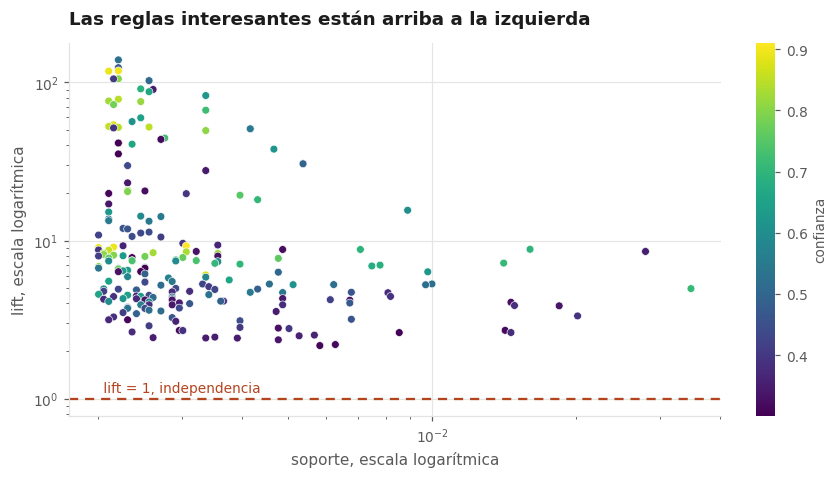

In [8]:
df_todas = spark.createDataFrame([Row(items=list(t)) for t in transacciones])
modelo = FPGrowth(itemsCol="items", minSupport=0.002, minConfidence=0.3).fit(df_todas)
r = modelo.associationRules.toPandas()
r["antecedente"] = r.antecedent.map(lambda a: " + ".join(nombre(x) for x in a))
r["consecuente"] = r.consequent.map(lambda c: " + ".join(nombre(x) for x in c))
r = (r[["antecedente", "consecuente", "support", "confidence", "lift"]]
     .rename(columns={"support": "soporte", "confidence": "confianza"})
     .sort_values("lift", ascending=False).reset_index(drop=True))
exportar(r.round(5), "p5_reglas", "Reglas de asociacion sobre canastas de entidad y mes")
print(f"{len(r):,} reglas con soporte >= 0.002 y confianza >= 0.3")

fig, ax = plt.subplots(figsize=(8.4, 4.4))
sc = ax.scatter(r.soporte, r.lift, c=r.confianza, s=26, cmap="viridis",
                edgecolors="white", linewidths=.4)
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("soporte, escala logarítmica"); ax.set_ylabel("lift, escala logarítmica")
ax.axhline(1, color=ROJO, lw=1.5, ls=(0, (4, 3)))
ax.text(r.soporte.min(), 1.1, " lift = 1, independencia", color=ROJO, fontsize=9)
cb = fig.colorbar(sc, ax=ax, fraction=.04); cb.set_label("confianza", fontsize=9)
cb.outline.set_visible(False)
ax.grid(alpha=.9); ax.set_axisbelow(True)
ax.set_title("Las reglas interesantes están arriba a la izquierda", loc="left", pad=12)
figura(fig, "f36_reglas", f"""
La nube muestra el compromiso central de la minería de reglas. Las reglas de soporte alto tienen
lift cercano a uno: describen ítems que coinciden por ser ambos frecuentes, no porque uno
prediga al otro. Las de lift alto viven en la zona de soporte bajo, donde el patrón es fuerte
pero afecta a pocas transacciones. El máximo de lift es {r.lift.max():,.0f}, es decir que ese par
aparece junto {r.lift.max():,.0f} veces más de lo que cabría esperar si fueran independientes.
Filtrar solo por confianza traería las reglas inútiles del borde derecho; por eso el criterio de
selección es lift alto con soporte suficiente para que la regla no sea una anécdota.""")
r.head(12).round(4)

In [9]:
# Las ocho reglas que el enunciado pide, elegidas con soporte y lift a la vez.
relevantes = r[(r.soporte >= 0.004) & (r.lift >= 3)].sort_values("lift", ascending=False).head(10)
exportar(relevantes.round(5), "p5_reglas_relevantes", "Diez reglas con soporte y lift relevantes")
for i, g in enumerate(relevantes.itertuples(), 1):
    print(f"{i:>2}. SI la entidad compra [{g.antecedente}]")
    print(f"    ENTONCES tambien compra [{g.consecuente}]")
    print(f"    soporte {g.soporte:.4f}  confianza {g.confianza:.3f}  lift {g.lift:.1f}\n")

 1. SI la entidad compra [CONSERVA DE ENTERO DE SARDINA PERUANA O ANCHOV]
    ENTONCES tambien compra [ACEITE VEGETAL COMESTIBLE]
    soporte 0.0042  confianza 0.386  lift 50.9

 2. SI la entidad compra [ACEITE VEGETAL COMESTIBLE]
    ENTONCES tambien compra [CONSERVA DE ENTERO DE SARDINA PERUANA O ANCHOV]
    soporte 0.0042  confianza 0.550  lift 50.9

 3. SI la entidad compra [ACEITE VEGETAL COMESTIBLE]
    ENTONCES tambien compra [ARROZ PILADO SUPERIOR]
    soporte 0.0047  confianza 0.616  lift 37.8

 4. SI la entidad compra [ARROZ PILADO SUPERIOR]
    ENTONCES tambien compra [CONSERVA DE ENTERO DE SARDINA PERUANA O ANCHOV]
    soporte 0.0054  confianza 0.330  lift 30.6

 5. SI la entidad compra [CONSERVA DE ENTERO DE SARDINA PERUANA O ANCHOV]
    ENTONCES tambien compra [ARROZ PILADO SUPERIOR]
    soporte 0.0054  confianza 0.498  lift 30.6

 6. SI la entidad compra [SERVICIO DE ALQUILER DE CAMION VOLQUETE + CEMENTO PORTLAND PUZOLANICO TIPO IP X 42.50 KG]
    ENTONCES tambien compra

## 5. Canasta enriquecida: dónde se concentra la falta de competencia

Hasta aquí la canasta tiene solo códigos de catálogo, así que las reglas hablan de qué se compra junto. Para responder la pregunta que dejó abierta la Parte I hay que agregar como ítems los atributos del proceso: el método, el nivel de gobierno, el tramo de monto y una marca de postor único.

In [10]:
enriquecida = spark.sql("""
    SELECT ocid,
           array_union(
             transform(items, x -> concat('RUBRO=', substr(x, 1, 4))),
             array(concat('METODO=', metodo),
                   concat('NIVEL=', nivel_gobierno),
                   CASE WHEN monto_pen <   50000 THEN 'TRAMO=menos de 50 mil'
                        WHEN monto_pen <  500000 THEN 'TRAMO=50 mil a 500 mil'
                        WHEN monto_pen < 5000000 THEN 'TRAMO=500 mil a 5 M'
                        ELSE                          'TRAMO=mas de 5 M' END,
                   CASE WHEN n_postores <= 1 THEN 'POSTOR=unico'
                        ELSE 'POSTOR=varios' END)) AS items
    FROM contrataciones WHERE NOT n_postores_imputado""")

m2 = FPGrowth(itemsCol="items", minSupport=0.004, minConfidence=0.25).fit(enriquecida)
r2 = m2.associationRules.toPandas()
r2["antecedente"] = r2.antecedent.map(lambda a: " + ".join(sorted(a)))
r2["consecuente"] = r2.consequent.map(lambda c: " + ".join(sorted(c)))
unico = (r2[r2.consecuente == "POSTOR=unico"]
         [["antecedente", "support", "confidence", "lift"]]
         .rename(columns={"support": "soporte", "confidence": "confianza"})
         .sort_values(["lift", "soporte"], ascending=False).head(12).reset_index(drop=True))
exportar(unico.round(5), "p5_postor_unico", "Condiciones asociadas a procesos con un solo postor")
unico.round(4)

,antecedente,soporte,confianza,lift
0,METODO=Regímen Especial + NIVEL=Gobierno nacional + TRAMO=me...,0.0176,1.0000,8.0611
1,METODO=Regímen Especial + NIVEL=Gobierno nacional + RUBRO=80...,0.0157,1.0000,8.0611
2,METODO=Regímen Especial + RUBRO=8010 + TRAMO=menos de 50 mil,0.0157,1.0000,8.0611
3,METODO=Contratación Internacional + RUBRO=8210,0.0058,1.0000,8.0611
4,METODO=Contratación Internacional + NIVEL=Gobierno nacional ...,0.0058,1.0000,8.0611
5,METODO=Regímen Especial + NIVEL=Gobierno nacional + RUBRO=8010,0.0171,0.9966,8.0336
6,METODO=Regímen Especial + TRAMO=menos de 50 mil,0.0177,0.9960,8.0293
7,METODO=Regímen Especial + RUBRO=8010,0.0171,0.9949,8.0200
8,METODO=Contratación Internacional + NIVEL=Gobierno nacional ...,0.0062,0.9944,8.0159
9,METODO=Contratación Directa + RUBRO=8013 + TRAMO=50 mil a 50...,0.0075,0.9900,7.9802



Lectura de f37_postor_unico
Esta figura responde la pregunta que quedó abierta en la Parte I: el suelo de procesos sin competencia no se reparte al azar. La tasa base de postor único es 12.4 %, de modo que el lift máximo posible es 8.1 y lo alcanza toda condición con confianza igual a uno. Hay 5 combinaciones empatadas en ese máximo, así que el ranking por lift no distingue entre ellas y se desempata por soporte: la más extendida es [METODO=Regímen Especial + NIVEL=Gobierno nacional + TRAMO=menos de 50 ], presente en el 1.8 % de los procesos. Que un régimen especial o una contratación internacional tengan un solo postor es administrativamente esperable y no indica nada irregular; el valor de la figura es acotar dónde buscar, y lo informativo son las combinaciones donde el procedimiento sí preveía concurrencia.



,antecedente,soporte,confianza,lift
0,METODO=Regímen Especial + NIVEL=Gobierno nacional + TRAMO=me...,0.018,1.000,8.061
1,METODO=Regímen Especial + NIVEL=Gobierno nacional + RUBRO=80...,0.016,1.000,8.061
2,METODO=Regímen Especial + RUBRO=8010 + TRAMO=menos de 50 mil,0.016,1.000,8.061
3,METODO=Contratación Internacional + RUBRO=8210,0.006,1.000,8.061
4,METODO=Contratación Internacional + NIVEL=Gobierno nacional ...,0.006,1.000,8.061
5,METODO=Regímen Especial + NIVEL=Gobierno nacional + RUBRO=8010,0.017,0.997,8.034
6,METODO=Regímen Especial + TRAMO=menos de 50 mil,0.018,0.996,8.029
7,METODO=Regímen Especial + RUBRO=8010,0.017,0.995,8.020
8,METODO=Contratación Internacional + NIVEL=Gobierno nacional ...,0.006,0.994,8.016
9,METODO=Contratación Directa + RUBRO=8013 + TRAMO=50 mil a 50...,0.008,0.990,7.980


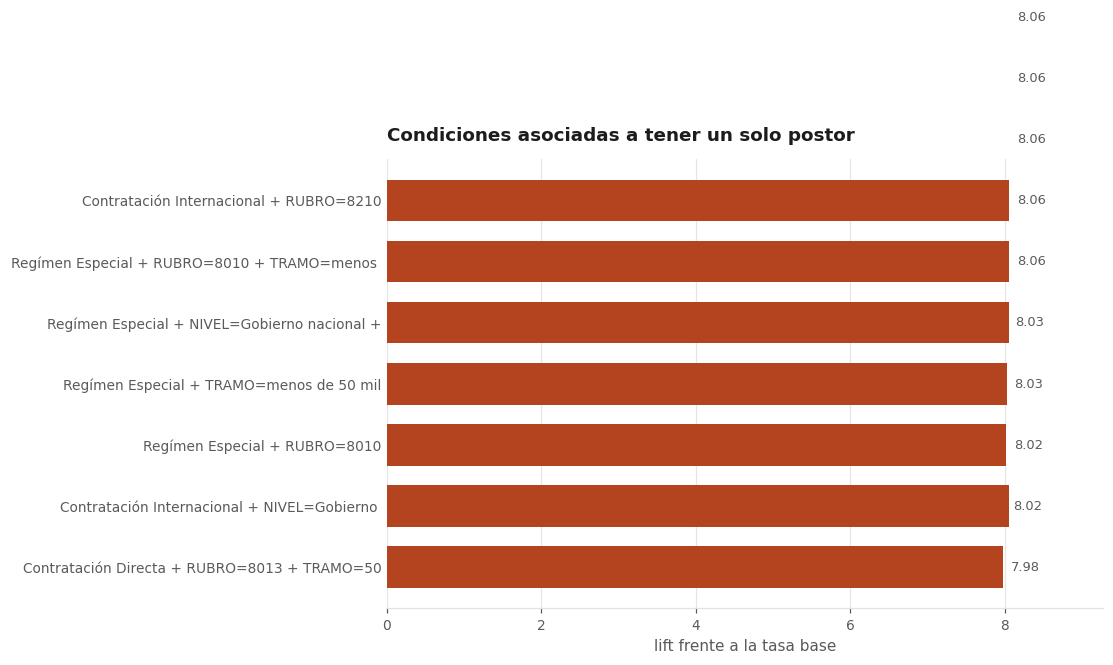

In [11]:
fig, _ = barras_h(unico.head(10).assign(
    cond=lambda d: d.antecedente.str.replace("METODO=", "").str.slice(0, 44)),
    "cond", "lift", "Condiciones asociadas a tener un solo postor",
    "lift frente a la tasa base", color=ROJO, alto=0.42)
base_unico = float(enriquecida.selectExpr(
    "AVG(CASE WHEN array_contains(items,'POSTOR=unico') THEN 1.0 ELSE 0.0 END) AS p"
).collect()[0]["p"])
top = unico.iloc[0]
empatadas = int((unico.confianza >= 0.999).sum())
figura(fig, "f37_postor_unico", f"""
Esta figura responde la pregunta que quedó abierta en la Parte I: el suelo de procesos sin
competencia no se reparte al azar. La tasa base de postor único es {100*base_unico:.1f} %, de
modo que el lift máximo posible es {1/base_unico:.1f} y lo alcanza toda condición con confianza
igual a uno. Hay {empatadas} combinaciones empatadas en ese máximo, así que el ranking por lift
no distingue entre ellas y se desempata por soporte: la más extendida es
[{top.antecedente[:70]}], presente en el {100*top.soporte:.1f} % de los procesos. Que un régimen
especial o una contratación internacional tengan un solo postor es administrativamente esperable
y no indica nada irregular; el valor de la figura es acotar dónde buscar, y lo informativo son
las combinaciones donde el procedimiento sí preveía concurrencia.""")
unico.head(10).round(3)

## 6. Cierre y advertencia

1. La definición de transacción era el problema real, no el algoritmo. La canasta natural no era minable y se redefinió con una medición de por medio.
2. A-Priori y FP-Growth devuelven exactamente los mismos conjuntos frecuentes sobre la misma muestra, lo que valida la implementación propia. Lo que los separa es el costo cuando baja el umbral.
3. El lift es el criterio de selección, no la confianza. Las reglas de confianza alta y lift cercano a uno son artefactos de frecuencia.
4. Una regla es una asociación estadística sobre datos de publicación, no una afirmación sobre la conducta de ninguna entidad ni proveedor. Señala dónde mirar y nada más. En datos de contratación pública esa distinción no es un formalismo: confundirla convierte un ejercicio de minería en una acusación sin sustento.

In [12]:
exportar(pd.DataFrame(FIGURAS), "p5_figuras", "Figuras de la Parte V con su lectura")
print(pd.DataFrame(FIGURAS).to_string(index=False))
spark.stop()

                    figura                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                   lectura
f34_definicion_transaccion                                                           Esta figura decide la parte entera, y da una respuesta incómoda: la definición natural no sirv